# **Process**

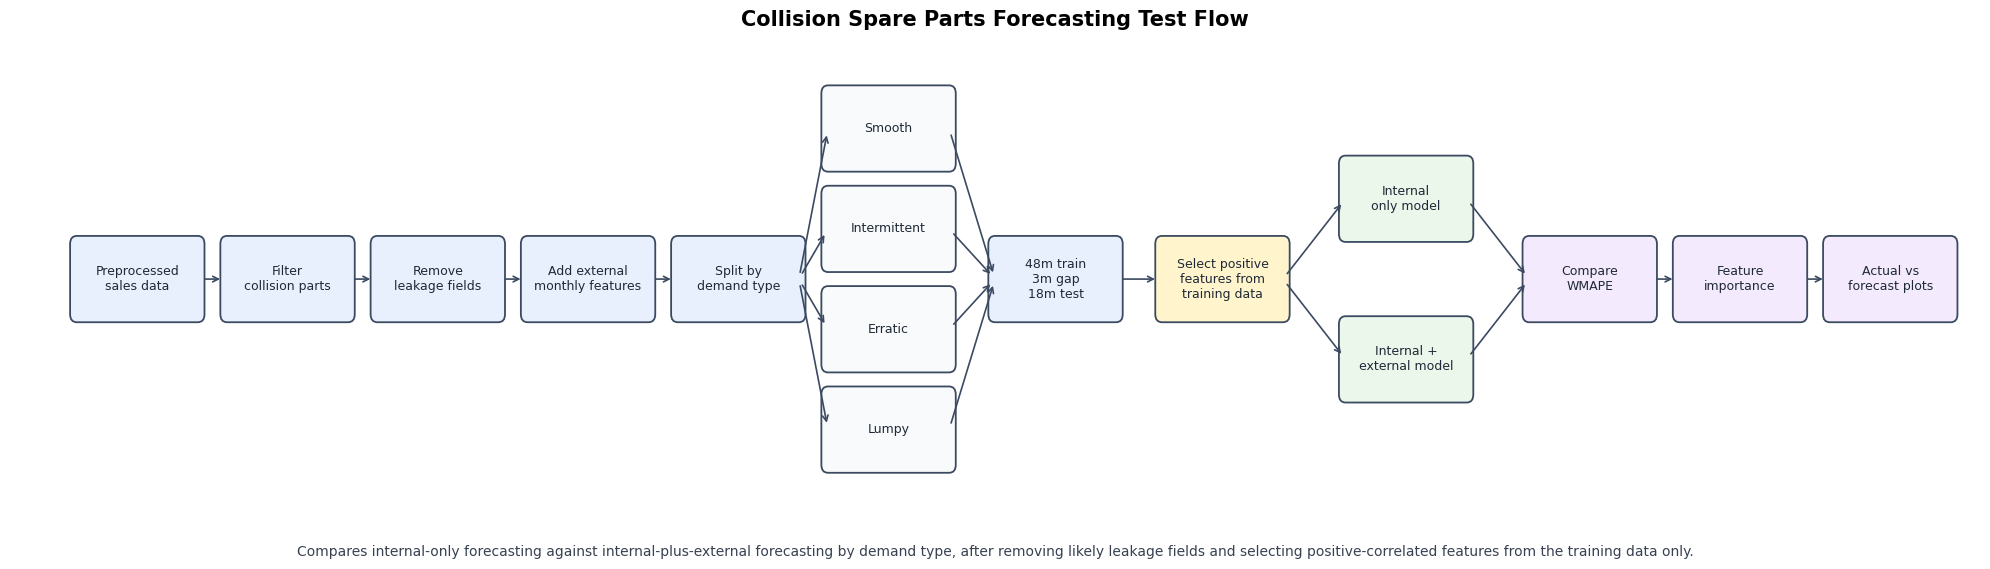

Saved flow diagram to: /content/drive/MyDrive/EP/collision_forecasting_flow.png


In [30]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

steps = [
    ("Preprocessed\nsales data", 0, 3),
    ("Filter\ncollision parts", 1.8, 3),
    ("Remove\nleakage fields", 3.6, 3),
    ("Add external\nmonthly features", 5.4, 3),
    ("Split by\ndemand type", 7.2, 3),

    ("Smooth", 9.0, 4.5),
    ("Intermittent", 9.0, 3.5),
    ("Erratic", 9.0, 2.5),
    ("Lumpy", 9.0, 1.5),

    ("48m train\n3m gap\n18m test", 11.0, 3),
    ("Select positive\nfeatures from\ntraining data", 13.0, 3),
    ("Internal\nonly model", 15.2, 3.8),
    ("Internal +\nexternal model", 15.2, 2.2),
    ("Compare\nWMAPE", 17.4, 3),
    ("Feature\nimportance", 19.2, 3),
    ("Actual vs\nforecast plots", 21.0, 3),
]

arrows = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (4, 5), (4, 6), (4, 7), (4, 8),
    (5, 9), (6, 9), (7, 9), (8, 9),
    (9, 10),
    (10, 11), (10, 12),
    (11, 13), (12, 13),
    (13, 14), (14, 15)
]

fig, ax = plt.subplots(figsize=(20, 5.5))
ax.set_xlim(-0.8, 22.8)
ax.set_ylim(0.5, 5.3)
ax.axis("off")

def add_box(text, x, y, color="#E8F0FE"):
    box = FancyBboxPatch(
        (x, y - 0.35),
        1.45,
        0.7,
        boxstyle="round,pad=0.08,rounding_size=0.08",
        linewidth=1.3,
        edgecolor="#3B4A60",
        facecolor=color
    )
    ax.add_patch(box)
    ax.text(
        x + 0.725,
        y,
        text,
        ha="center",
        va="center",
        fontsize=9,
        color="#1F2937"
    )

for i, (text, x, y) in enumerate(steps):
    color = "#E8F0FE"

    if i in [5, 6, 7, 8]:
        color = "#F8FAFC"

    if i == 10:
        color = "#FFF4CC"

    if i in [11, 12]:
        color = "#EAF7EA"

    if i in [13, 14, 15]:
        color = "#F4EAFE"

    add_box(text, x, y, color)

for start, end in arrows:
    _, x1, y1 = steps[start]
    _, x2, y2 = steps[end]

    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1 + 1.45, y1),
        arrowprops=dict(
            arrowstyle="->",
            color="#3B4A60",
            linewidth=1.2,
            shrinkA=5,
            shrinkB=5
        )
    )

plt.title(
    "Collision Spare Parts Forecasting Test Flow",
    fontsize=15,
    weight="bold",
    pad=16
)

caption = (
    "Compares internal-only forecasting against internal-plus-external forecasting "
    "by demand type, after removing likely leakage fields and selecting "
    "positive-correlated features from the training data only."
)

plt.figtext(
    0.5,
    -0.02,
    caption,
    ha="center",
    fontsize=10,
    color="#374151"
)

plt.tight_layout()

output_path = "/content/drive/MyDrive/EP/collision_forecasting_flow.png"
plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved flow diagram to: {output_path}")

# **Import and Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

In [2]:
#import data

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
sales = pd.read_csv(
    "/content/drive/MyDrive/EP/External Data/processed/preprocessed_collision_sales.csv"
)

external = pd.read_csv(
    "/content/drive/MyDrive/EP/External Data/processed/monthly_external_features.csv"
)

sales["date"] = pd.to_datetime(sales["date"])
external["date"] = pd.to_datetime(external["date"])

sales = sales.merge(
    external,
    on="date",
    how="left"
)

In [4]:
collision_sales = sales[sales["is_collision"] == True].copy()

In [5]:
collision_sales.head(10)

,ts_id,COUNTRY_BRAND_CHANNEL,Country,Brand,Channel,Date,REVENUE,COST,UNIT_PRICE,TOTAL_PROFIT,...,avg_snowfall_sum,avg_precipitation_hours,max_wind_speed,max_wind_gust,avg_rain_days,weather_locations,days_in_month,weekend_days,public_holidays,working_days
176,01550M0612A,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,2024-10-01,NaN,NaN,NaN,NaN,...,0.04,71.571429,72.2,127.8,10.857143,7.0,31.0,8.0,2.0,22.0
180,01550M0612A,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,2025-06-01,NaN,NaN,NaN,NaN,...,1.47,85.571429,49.6,102.6,11.857143,7.0,30.0,9.0,3.0,20.0
183,01550M0612A,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,2024-11-01,NaN,NaN,NaN,NaN,...,0.41,70.857143,47.2,99.4,9.285714,7.0,30.0,9.0,1.0,20.0
184,01550M0612A,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,2024-12-01,NaN,NaN,NaN,NaN,...,0.03,49.857143,42.8,98.3,7.000000,7.0,31.0,9.0,2.0,21.0
197,01550M0612A,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,2026-04-01,NaN,NaN,NaN,NaN,...,0.55,55.714286,49.6,96.8,8.142857,7.0,30.0,8.0,2.0,21.0
200,01550M0612A,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,2025-08-01,NaN,NaN,NaN,NaN,...,3.56,103.285714,49.5,96.8,11.285714,7.0,31.0,10.0,1.0,20.0
203,01550M0612A,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,2026-02-01,NaN,NaN,NaN,NaN,...,0.00,46.714286,50.4,97.6,7.142857,7.0,28.0,8.0,0.0,20.0
204,01550M0612A,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,2025-04-01,NaN,NaN,NaN,NaN,...,0.02,51.142857,49.1,97.9,6.714286,7.0,30.0,8.0,2.0,21.0
206,01550M0612A,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,2025-09-01,NaN,NaN,NaN,NaN,...,0.33,62.285714,50.8,100.1,8.857143,7.0,30.0,8.0,2.0,20.0
207,01550M0612A,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,2025-11-01,NaN,NaN,NaN,NaN,...,0.03,56.000000,51.4,106.6,8.000000,7.0,30.0,10.0,1.0,20.0


# **Demand Type**

In [6]:
sku_demand_type_distribution = (
    collision_sales
    .drop_duplicates(["sku_id", "demand_type"])
    .groupby("demand_type", as_index=False)
    .agg(
        sku_count=("sku_id", "nunique")
    )
    .sort_values("sku_count", ascending=False)
)

sku_demand_type_distribution

,demand_type,sku_count
1,Intermittent,6099
4,Smooth,904
2,Lumpy,690
0,Erratic,396
3,No demand observed,8


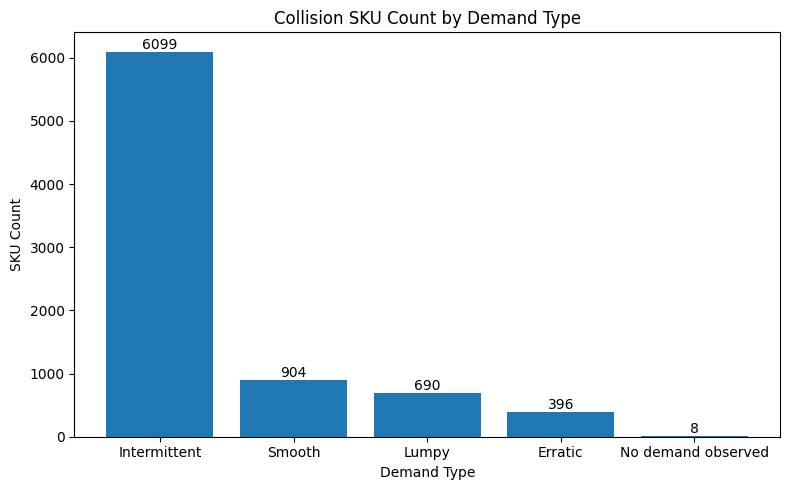

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
bars = plt.bar(
    sku_demand_type_distribution["demand_type"],
    sku_demand_type_distribution["sku_count"]
)

plt.title("Collision SKU Count by Demand Type")
plt.xlabel("Demand Type")
plt.ylabel("SKU Count")

for bar, value in zip(
    bars,
    sku_demand_type_distribution["sku_count"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# **Helper Functions**

In [8]:
def wmape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.sum(np.abs(y_true))
    return np.nan if denom == 0 else np.sum(np.abs(y_true - y_pred)) / denom


def create_time_split(data, date_col="date", train_months=48, gap_months=3, test_months=18):
    data = data.copy()
    data[date_col] = pd.to_datetime(data[date_col])
    data = data.sort_values(date_col)

    last_date = data[date_col].max()

    test_end = last_date
    test_start = test_end - pd.DateOffset(months=test_months) + pd.DateOffset(months=1)

    gap_end = test_start - pd.DateOffset(months=1)
    gap_start = gap_end - pd.DateOffset(months=gap_months) + pd.DateOffset(months=1)

    train_end = gap_start - pd.DateOffset(months=1)
    train_start = train_end - pd.DateOffset(months=train_months) + pd.DateOffset(months=1)

    train = data[
        (data[date_col] >= train_start)
        & (data[date_col] <= train_end)
    ].copy()

    test = data[
        (data[date_col] >= test_start)
        & (data[date_col] <= test_end)
    ].copy()

    return train, test, {
        "train_start": train_start,
        "train_end": train_end,
        "gap_start": gap_start,
        "gap_end": gap_end,
        "test_start": test_start,
        "test_end": test_end
    }


def get_feature_sets(data, externals):
    id_cols = [
        "sku_id",
        "date",
        "demand",
        "is_collision",
        "demand_type",
        "year",
        "month"
    ]

    external_feature_cols = [
        col for col in external.columns
        if col in data.columns
        and col not in ["date", "year", "month"]
    ]

    all_numeric_cols = data.select_dtypes(include="number").columns.tolist()

    internal_feature_cols = [
        col for col in all_numeric_cols
        if col not in id_cols
        and col not in external_feature_cols
    ]

    both_feature_cols = internal_feature_cols + external_feature_cols

    return internal_feature_cols, external_feature_cols, both_feature_cols


def train_and_score_rf(train, test, feature_cols, model_name):
    X_train = train[feature_cols].fillna(0)
    y_train = train["demand"]

    X_test = test[feature_cols].fillna(0)
    y_test = test["demand"]

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    preds = np.clip(preds, 0, None)

    score = wmape(y_test, preds)

    feature_importance = (
        pd.DataFrame({
            "feature": feature_cols,
            "importance": model.feature_importances_
        })
        .sort_values("importance", ascending=False)
    )

    forecast_results = test[["sku_id", "date", "demand"]].copy()
    forecast_results["forecast"] = preds
    forecast_results["model"] = model_name

    return {
        "model_name": model_name,
        "wmape": score,
        "wmape_percent": score * 100,
        "feature_count": len(feature_cols),
        "model": model,
        "feature_importance": feature_importance,
        "forecast_results": forecast_results
    }

def select_positive_features(train, feature_cols, target_col="demand", min_corr=0):
    corr = (
        train[feature_cols + [target_col]]
        .corr(numeric_only=True)[target_col]
        .drop(target_col)
        .dropna()
        .sort_values(ascending=False)
    )

    positive_features = corr[corr > min_corr].index.tolist()

    return positive_features, corr.reset_index().rename(
        columns={"index": "feature", target_col: "correlation_with_demand"}
    )

leakage_features_to_remove = [
    "REVENUE",
    "COST",
    "UNIT_PRICE",
    "TOTAL_PROFIT",
    "UNIT_COST",
    "STOCK_END_MONTH",
    "value",
    "demand",
    "total_demand",
    "mean_monthly_demand",
    "max_monthly_demand",
    "months_with_demand",
    "zero_demand_months",
    "zero_month_share",
    "cumulative_demand_share",
    "cumulative_sku_share",
    "average_demand_interval",
    "squared_coefficient_of_variation",
    "demand_type",
    "collision_flag",
    "collision_flag_clean",
    "is_collision",
    "month_x",
    "month_y"
]

def remove_likely_leakage_features(feature_cols):
    return [
        col for col in feature_cols
        if col not in leakage_features_to_remove
    ]

# **Forecasting loop**

In [9]:
demand_types_to_run = ["smooth", "intermittent", "erratic", "lumpy"]

all_comparison_results = []
all_feature_importance = []
all_forecast_results = []
all_selected_features = []

for demand_type_to_run in demand_types_to_run:

    print(f"Running: {demand_type_to_run}")

    demand_sales = sales[
        sales["demand_type"].astype(str).str.lower().eq(demand_type_to_run)
    ].copy()

    if demand_sales.empty:
        print(f"Skipping {demand_type_to_run}: no rows")
        continue

    train, test, split_info = create_time_split(
        demand_sales,
        train_months=48,
        gap_months=3,
        test_months=18
    )

    if train.empty or test.empty:
        print(f"Skipping {demand_type_to_run}: empty train/test")
        continue

    internal_feature_cols, external_feature_cols, both_feature_cols = get_feature_sets(
        demand_sales,
        external
    )

    internal_feature_cols = remove_likely_leakage_features(internal_feature_cols)
    both_feature_cols = remove_likely_leakage_features(both_feature_cols)

    internal_positive_features, internal_corr = select_positive_features(
        train,
        internal_feature_cols
    )

    both_positive_features, both_corr = select_positive_features(
        train,
        both_feature_cols
    )

    selected_features_summary = pd.DataFrame({
        "demand_type": demand_type_to_run,
        "model": ["Internal only", "Internal + external"],
        "feature_count_before": [len(internal_feature_cols), len(both_feature_cols)],
        "feature_count_after_positive_filter": [
            len(internal_positive_features),
            len(both_positive_features)
        ]
    })

    all_selected_features.append(selected_features_summary)

    feature_sets = {
        "Internal only": internal_positive_features,
        "Internal + external": both_positive_features
    }

    for model_label, cols in feature_sets.items():

        if len(cols) == 0:
            print(f"Skipping {demand_type_to_run} - {model_label}: no positive features")
            continue

        result = train_and_score_rf(
            train=train,
            test=test,
            feature_cols=cols,
            model_name=model_label
        )

        all_comparison_results.append({
            "demand_type": demand_type_to_run,
            "model": model_label,
            "feature_count": result["feature_count"],
            "wmape": result["wmape"],
            "wmape_percent": result["wmape_percent"],
            "train_start": split_info["train_start"],
            "train_end": split_info["train_end"],
            "test_start": split_info["test_start"],
            "test_end": split_info["test_end"],
            "train_rows": len(train),
            "test_rows": len(test),
            "sku_count": demand_sales["sku_id"].nunique()
        })

        feature_importance = result["feature_importance"].copy()
        feature_importance["demand_type"] = demand_type_to_run
        feature_importance["model"] = model_label
        feature_importance["is_external_feature"] = feature_importance["feature"].isin(
            external_feature_cols
        )

        all_feature_importance.append(feature_importance)

        forecast_results = result["forecast_results"].copy()
        forecast_results["demand_type"] = demand_type_to_run
        forecast_results["model"] = model_label

        all_forecast_results.append(forecast_results)



Running: smooth
Running: intermittent
Running: erratic
Running: lumpy


# **Results**

In [15]:
# Build final result tables after the demand-type forecast loop

comparison_results_all = pd.DataFrame(all_comparison_results)

feature_importance_all = pd.concat(
    all_feature_importance,
    ignore_index=True
) if len(all_feature_importance) > 0 else pd.DataFrame()

forecast_results_all = pd.concat(
    all_forecast_results,
    ignore_index=True
) if len(all_forecast_results) > 0 else pd.DataFrame()

selected_features_all = pd.concat(
    all_selected_features,
    ignore_index=True
) if "all_selected_features" in globals() and len(all_selected_features) > 0 else pd.DataFrame()

In [16]:
# Main WMAPE comparison table

comparison_results_all = comparison_results_all.sort_values(
    ["demand_type", "model"]
).reset_index(drop=True)

comparison_results_all

,demand_type,model,feature_count,wmape,wmape_percent,train_start,train_end,test_start,test_end,train_rows,test_rows,sku_count
0,erratic,Internal + external,20,0.858422,85.842212,2020-08-01,2024-07-01,2024-11-01,2026-04-01,27059,12461,699
1,erratic,Internal only,13,0.854435,85.443483,2020-08-01,2024-07-01,2024-11-01,2026-04-01,27059,12461,699
2,intermittent,Internal + external,19,0.422908,42.290778,2020-08-01,2024-07-01,2024-11-01,2026-04-01,440089,267221,15534
3,intermittent,Internal only,11,0.460734,46.073351,2020-08-01,2024-07-01,2024-11-01,2026-04-01,440089,267221,15534
4,lumpy,Internal + external,19,0.694471,69.447060,2020-08-01,2024-07-01,2024-11-01,2026-04-01,56606,27676,1555
5,lumpy,Internal only,11,0.706996,70.699636,2020-08-01,2024-07-01,2024-11-01,2026-04-01,56606,27676,1555
6,smooth,Internal + external,22,0.707745,70.774497,2020-08-01,2024-07-01,2024-11-01,2026-04-01,46808,21350,1303
7,smooth,Internal only,12,0.705068,70.506759,2020-08-01,2024-07-01,2024-11-01,2026-04-01,46808,21350,1303


In [17]:
# Feature count summary after positive-feature filtering

selected_features_all

,demand_type,model,feature_count_before,feature_count_after_positive_filter
0,smooth,Internal only,33,12
1,smooth,Internal + external,67,22
2,intermittent,Internal only,33,11
3,intermittent,Internal + external,67,19
4,erratic,Internal only,33,13
5,erratic,Internal + external,67,20
6,lumpy,Internal only,33,11
7,lumpy,Internal + external,67,19


In [18]:
# Improvement summary: positive means external data improved WMAPE

improvement_summary = (
    comparison_results_all
    .pivot_table(
        index="demand_type",
        columns="model",
        values="wmape_percent",
        aggfunc="first"
    )
    .reset_index()
)

if "Internal only" in improvement_summary.columns and "Internal + external" in improvement_summary.columns:
    improvement_summary["external_improvement_points"] = (
        improvement_summary["Internal only"]
        - improvement_summary["Internal + external"]
    )

    improvement_summary["external_improved"] = (
        improvement_summary["external_improvement_points"] > 0
    )

improvement_summary

model,demand_type,Internal + external,Internal only,external_improvement_points,external_improved
0,erratic,85.842212,85.443483,-0.398729,False
1,intermittent,42.290778,46.073351,3.782573,True
2,lumpy,69.447060,70.699636,1.252576,True
3,smooth,70.774497,70.506759,-0.267738,False


In [19]:
# Top feature importance by demand type and model

top_feature_importance = (
    feature_importance_all
    .sort_values(
        ["demand_type", "model", "importance"],
        ascending=[True, True, False]
    )
    .groupby(["demand_type", "model"])
    .head(20)
    .reset_index(drop=True)
)

top_feature_importance

,feature,importance,demand_type,model,is_external_feature
0,NEW_ENTRY_STOCK,0.972395,erratic,Internal + external,False
1,Inflation_Rate_MoM,0.006029,erratic,Internal + external,False
2,STOCK_START_MONTH,0.002793,erratic,Internal + external,False
3,Imports,0.002308,erratic,Internal + external,False
4,min_temperature,0.002204,erratic,Internal + external,True
...,...,...,...,...,...
120,Core_Inflation_Rate,0.000718,smooth,Internal only,False
121,Inflation_Rate,0.000586,smooth,Internal only,False
122,Building_Permits,0.000512,smooth,Internal only,False
123,Leading_Economic_Index,0.000344,smooth,Internal only,False


In [20]:
# External feature importance only

external_feature_importance = (
    feature_importance_all[
        feature_importance_all["is_external_feature"].eq(True)
    ]
    .sort_values(
        ["demand_type", "model", "importance"],
        ascending=[True, True, False]
    )
    .reset_index(drop=True)
)

external_feature_importance

,feature,importance,demand_type,model,is_external_feature
0,min_temperature,0.002204,erratic,Internal + external,True
1,lag_1yr_national_annual_injuries_per_10k_vehic...,0.001676,erratic,Internal + external,True
2,max_temperature,0.001487,erratic,Internal + external,True
3,lag_1yr_national_annual_fatalities_per_10k_veh...,0.001311,erratic,Internal + external,True
4,lag_1yr_national_annual_motorization_rate_context,0.001202,erratic,Internal + external,True
5,working_days,0.001097,erratic,Internal + external,True
6,lag_1yr_national_annual_fatalities_per_100_col...,0.000161,erratic,Internal + external,True
7,avg_temperature,0.001549,intermittent,Internal + external,True
8,lag_1yr_national_annual_motorization_rate_context,0.001004,intermittent,Internal + external,True
9,lag_1yr_national_annual_fatalities_per_10k_veh...,0.000937,intermittent,Internal + external,True


In [26]:
# Forecast results aggregated by month and model

forecast_by_month_type = (
    forecast_results_all
    .groupby(["demand_type", "date", "model"], as_index=False)
    .agg(
        actual=("demand", "sum"),
        forecast=("forecast", "sum")
    )
)

forecast_by_month_type

,demand_type,date,model,actual,forecast
0,erratic,2024-11-01,Internal + external,4077.0,5332.144627
1,erratic,2024-11-01,Internal only,4077.0,5341.665325
2,erratic,2024-12-01,Internal + external,4113.0,5746.759592
3,erratic,2024-12-01,Internal only,4113.0,5506.202335
4,erratic,2025-01-01,Internal + external,4526.0,5421.295932
...,...,...,...,...,...
139,smooth,2026-02-01,Internal only,17323.0,19497.247163
140,smooth,2026-03-01,Internal + external,17926.0,20069.598537
141,smooth,2026-03-01,Internal only,17926.0,19775.926229
142,smooth,2026-04-01,Internal + external,17236.0,15912.945948


# **Visuals**

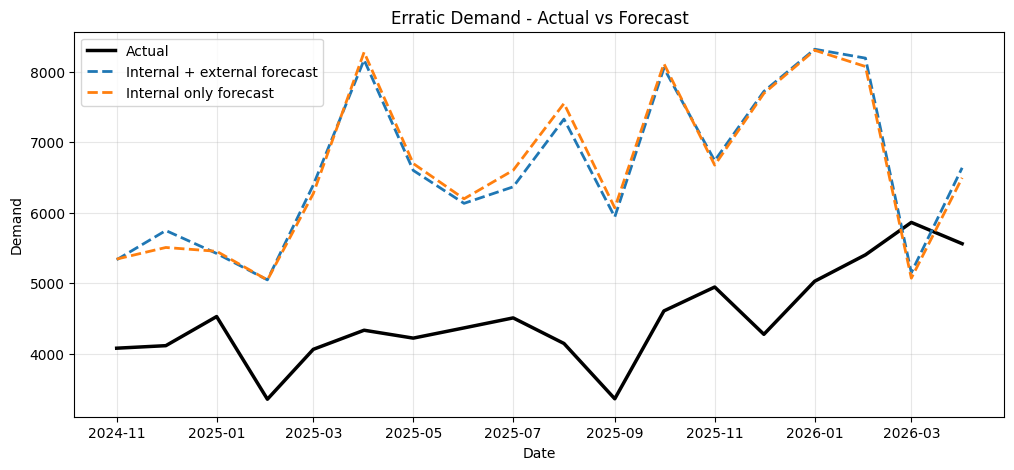

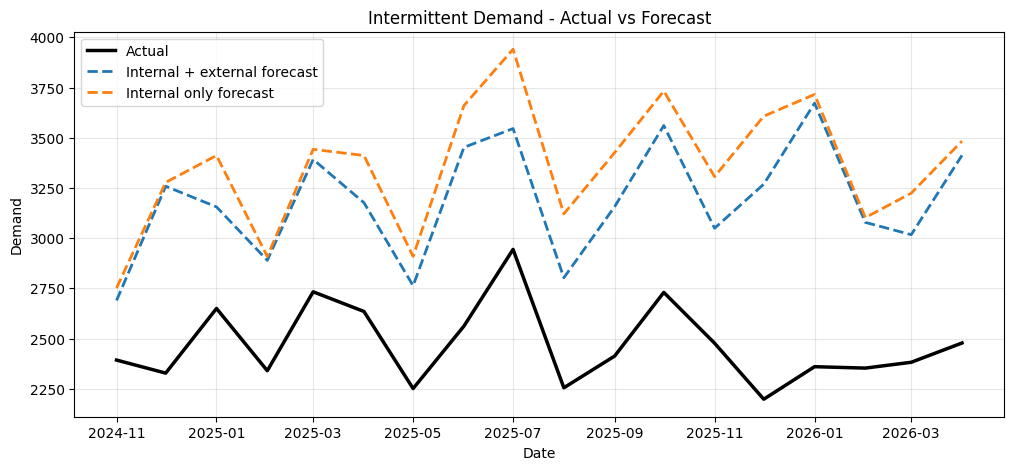

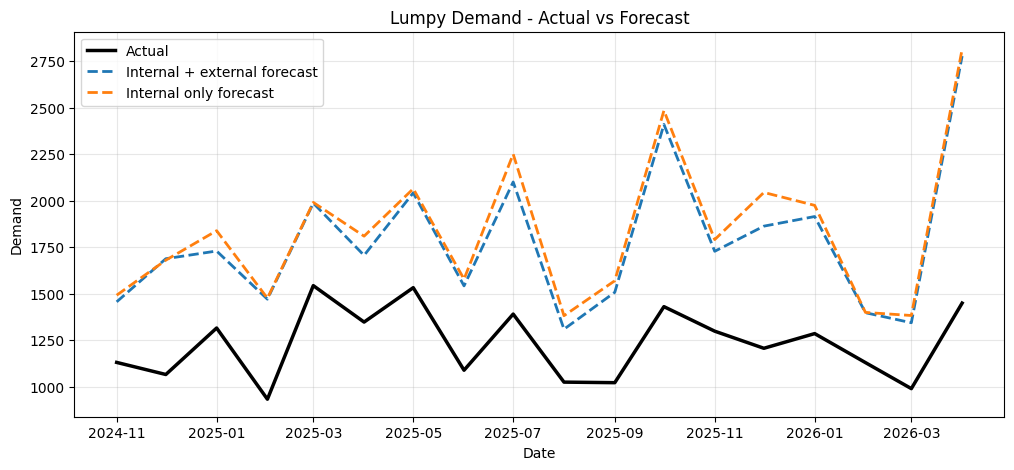

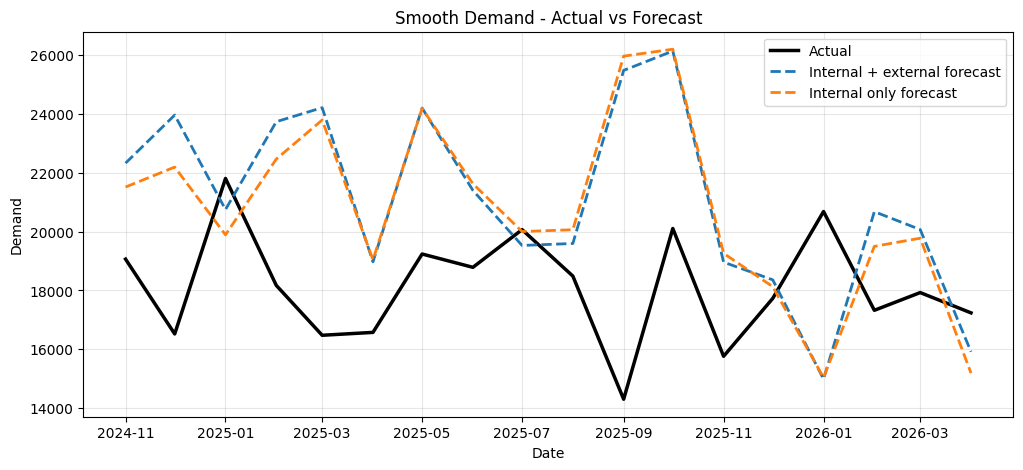

In [28]:
#Plot the results

import matplotlib.pyplot as plt

for demand_type in forecast_by_month_type["demand_type"].dropna().unique():

    plot_data = forecast_by_month_type[
        forecast_by_month_type["demand_type"].eq(demand_type)
    ].copy()

    plt.figure(figsize=(12, 5))

    actual_data = (
        plot_data
        .groupby("date", as_index=False)
        .agg(actual=("actual", "first"))
    )

    plt.plot(
        actual_data["date"],
        actual_data["actual"],
        label="Actual",
        linewidth=2.5,
        color="black"
    )

    for model_name in plot_data["model"].dropna().unique():

        model_data = plot_data[
            plot_data["model"].eq(model_name)
        ].copy()

        plt.plot(
            model_data["date"],
            model_data["forecast"],
            label=f"{model_name} forecast",
            linestyle="--",
            linewidth=2
        )

    plt.title(f"{demand_type.title()} Demand - Actual vs Forecast")
    plt.xlabel("Date")
    plt.ylabel("Demand")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()